# ResNet50: with 4 layers: together: 16 Bottleneck blocks
## blocks in layer [3, 4, 6, 3]: layer1= 3 blocks, layer2= 4 blocks,layer3=6 blocks, layer4= 3 blocks
## Bottleneck Block (ResNet-50 Style): Bottleneck blocks with layers = [3, 4, 6, 3]
## image size will be reduced half every layer
## the reduction happens in the first block of every layer. Other blocks do not reduce the image size

https://machinelearningknowledge.ai/popular-image-classification-models-in-imagenet-challenge-ilsvrc-competition-history/

prompt: **zeige CIFAR-10 Bilder**, zeige ImageNet Bilder:

https://www.researchgate.net/figure/mage-examples-from-the-CIFAR-10-dataset-1-truck-2-ship-3-horse-4-frog-5-dog-6_fig3_373929378


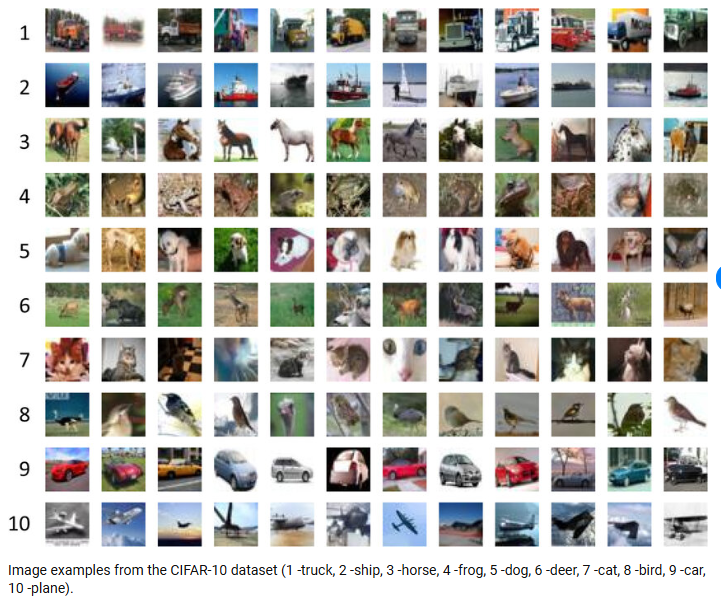


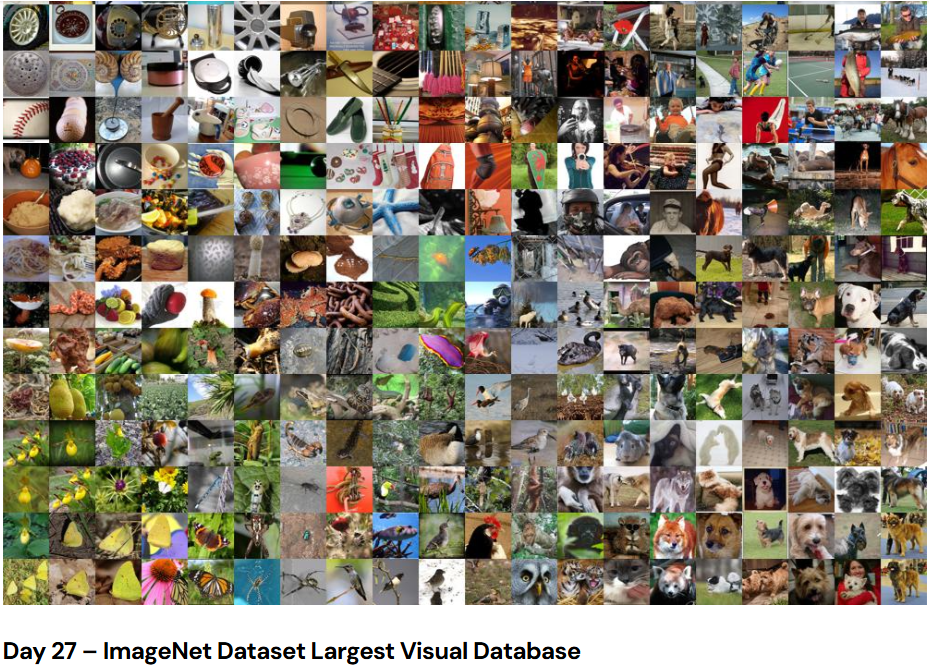

Bottleneck (ResNet-50/101/152)

1×1 → 3×3 → 1×1

channels: C → C → 4C

Warum stoppen bei 152? Diminishing Returns + Compute-Kosten 

    -> EfficientNet, 
    -> RegNet, 
    -> Vision Transformers besser heute.

## Wird x mit der Tiefe verdrängt?

Schauen wir rekursiv:
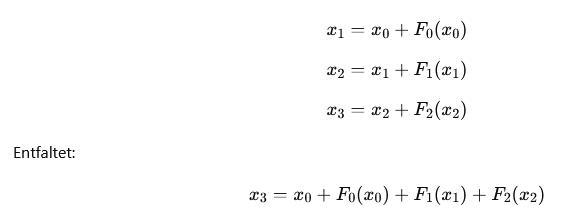

Das bedeutet:

👉 Frühere Information wird akkumuliert
👉 Sie wird nicht ersetzt
👉 Aber sie wird zunehmend transformiert

Also nicht:

F verdrängt x

Sondern:

Neue Residuen werden auf alte Information aufaddiert

https://arxiv.org/pdf/1512.03385

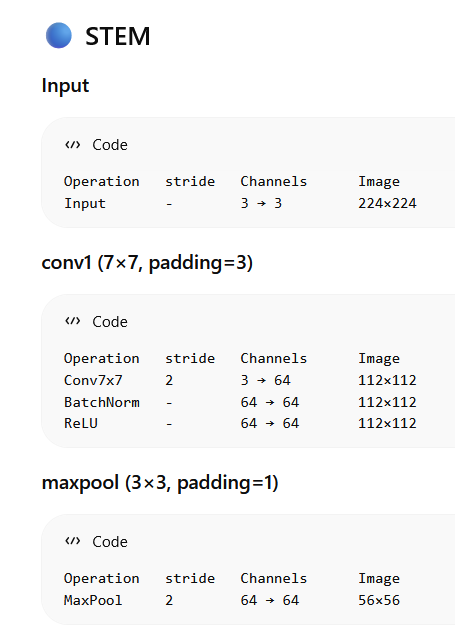

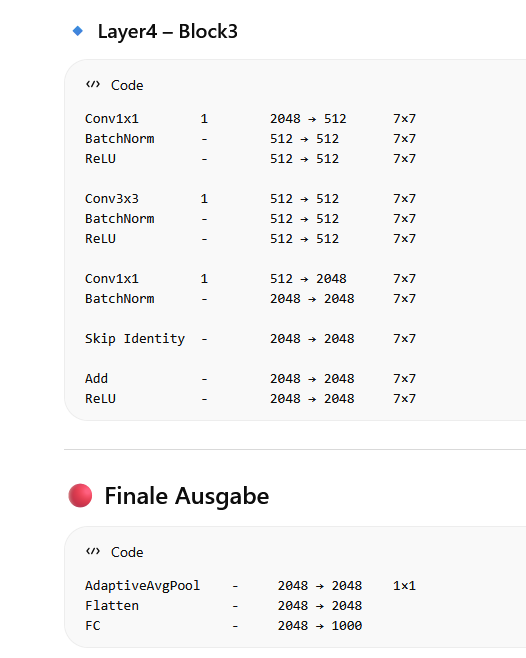

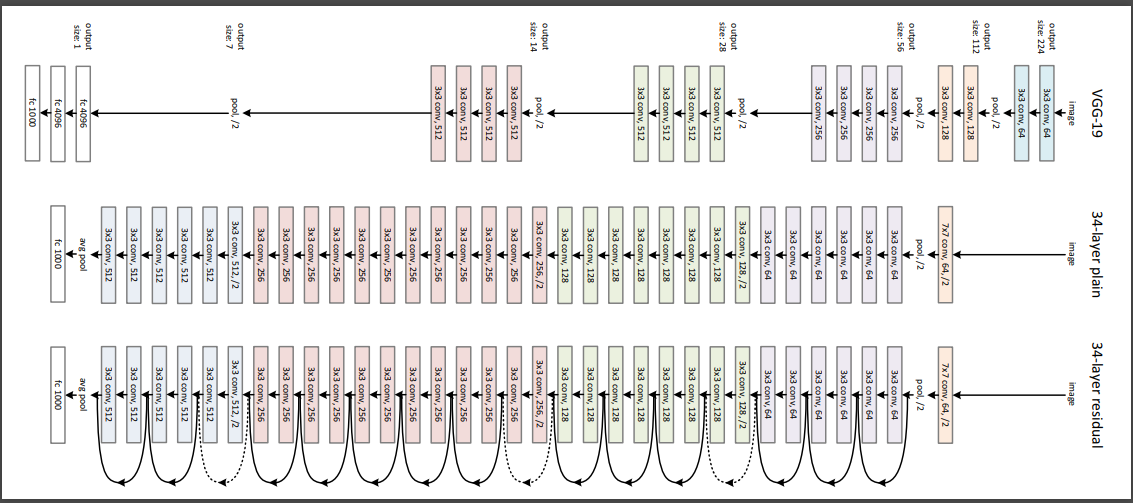


In [2]:

#Bottleneck Block

import torch
import torch.nn as nn
import torch.nn.functional as F

def conv1x1(in_planes, out_planes, stride=1):
    """
    1x1 convolution.
    Used for channel reduction/expansion and downsampling.
    """
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=1,
        stride=stride,
        bias=False
    )

def conv3x3(in_planes, out_planes, stride=1):
    """
    3x3 convolution with padding.
    """
    return nn.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )

class Bottleneck(nn.Module):
    """
    Bottleneck residual block used in ResNet-50, ResNet-101, ResNet-152.

    Structure:
        x -> 1x1 Conv (reduce channels)
           -> 3x3 Conv (spatial processing)
           -> 1x1 Conv (expand channels)
           -> + skip connection
           -> ReLU
    """
    expansion = 4  # Output channels = planes * 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()

        # 1x1 convolution: channel reduction
        self.conv1 = conv1x1(inplanes, planes)
        self.bn1 = nn.BatchNorm2d(planes)

        # 3x3 convolution: spatial feature extraction
        self.conv2 = conv3x3(planes, planes, stride)
        self.bn2 = nn.BatchNorm2d(planes)

        # 1x1 convolution: channel expansion
        self.conv3 = conv1x1(planes, planes * self.expansion)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        # Channel reduction
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Spatial processing
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        # Channel expansion
        out = self.conv3(out)
        out = self.bn3(out)

        # Match identity dimensions if needed
        if self.downsample is not None:
            identity = self.downsample(x)

        # Residual addition
        out += identity
        out = self.relu(out)

        return out

# ResNet mit Bottleneck-Blocks

👉 Wichtig: block.expansion = 4 wirkt sich direkt auf Channel-Zahlen aus.

In [3]:
class ResNet(nn.Module):
    """
    Generic ResNet architecture supporting Bottleneck blocks.
    """
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.inplanes = 64

        # Initial convolution (stem)
        self.conv1 = nn.Conv2d(
            3, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual stages
        self.layer1 = self._make_layer(block, 64,  layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Classification head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        """
        Builds one ResNet stage with Bottleneck blocks.
        """
        downsample = None

        # Downsampling if resolution or channel size changes
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []

        # First block (may downsample)
        # stride=2 used only for block 1 in conv2d3x3() in every layer
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion

        # Remaining blocks: stride=1 for all the blocks due to block(self.inplanes, planes)
        # using the default stride=1
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        # Stem
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Residual stages
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        # Pooling and classification
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

# ResNet-50 Konstruktor

In [4]:
def resnet50(num_classes=1000):
    """
    Constructs a ResNet-50 model.

    Configuration:
        Bottleneck blocks with layers = [3, 4, 6, 3]
    """
    return ResNet(Bottleneck, [3, 4, 6, 3], num_classes)

In [6]:
# ResNet-50 Modell erstellen
model = resnet50(num_classes=1000)

# Modell in den Evaluierungsmodus versetzen (deaktiviert Dropout/BatchNorm-Update)
model.eval()

# Beispiel-Eingabe (BatchSize=1, Channels=3, Height=224, Width=224)
dummy_input = torch.randn(2, 3, 224, 224)

# Forward Pass ohne Gradientenberechnung (spart Speicher)
with torch.no_grad():
    output = model(dummy_input)

print(f"Modell-Typ: ResNet-50")
print(f"Eingabe-Form: {dummy_input.shape}")
print(f"Ausgabe-Form (Klassen-Logits): {output.shape}")

# Zeige die ersten 5 Logits
print(f"Erste 5 Logits: {output[0][:5]}")

# Optional: Softmax für Wahrscheinlichkeiten
probabilities = torch.nn.functional.softmax(output[0], dim=0)
print(f"Erste 5 Wahrscheinlichkeiten: {probabilities[:5]}")


Modell-Typ: ResNet-50
Eingabe-Form: torch.Size([2, 3, 224, 224])
Ausgabe-Form (Klassen-Logits): torch.Size([2, 1000])
Erste 5 Logits: tensor([-0.0093, -0.0313, -0.0120,  0.0182,  0.0133])
Erste 5 Wahrscheinlichkeiten: tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010])
